In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')

In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

/tmp/ipykernel_1239/4028183633.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df, palette='pastel')


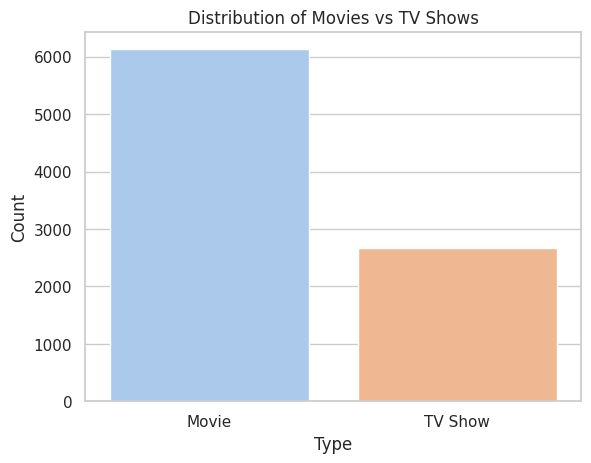

In [ ]:
sns.countplot(x='type', data=df, palette='pastel')
plt.title('Distribution of Movies vs TV Shows')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

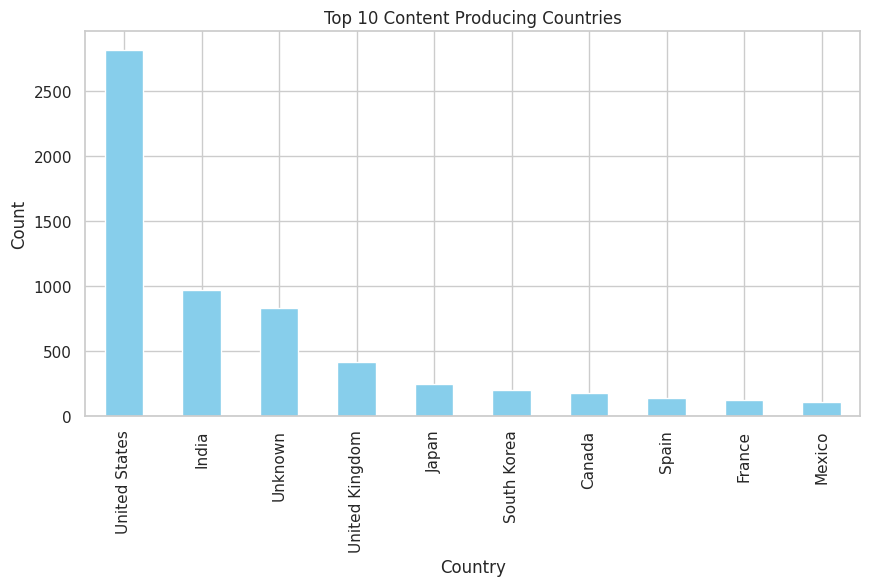

In [ ]:
plt.figure(figsize=(10,5))
df['country'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Content Producing Countries')
plt.xlabel('Country')
plt.ylabel('Count')
plt.show()

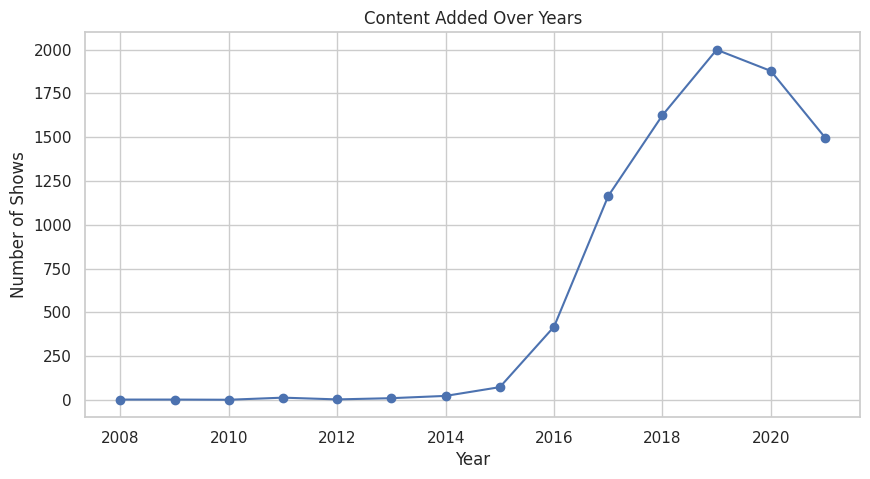

In [ ]:
plt.figure(figsize=(10,5))
df['year_added'].value_counts().sort_index().plot(marker='o')
plt.title('Content Added Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Shows')
plt.show()

/tmp/ipykernel_1239/368720874.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='rating', data=df,


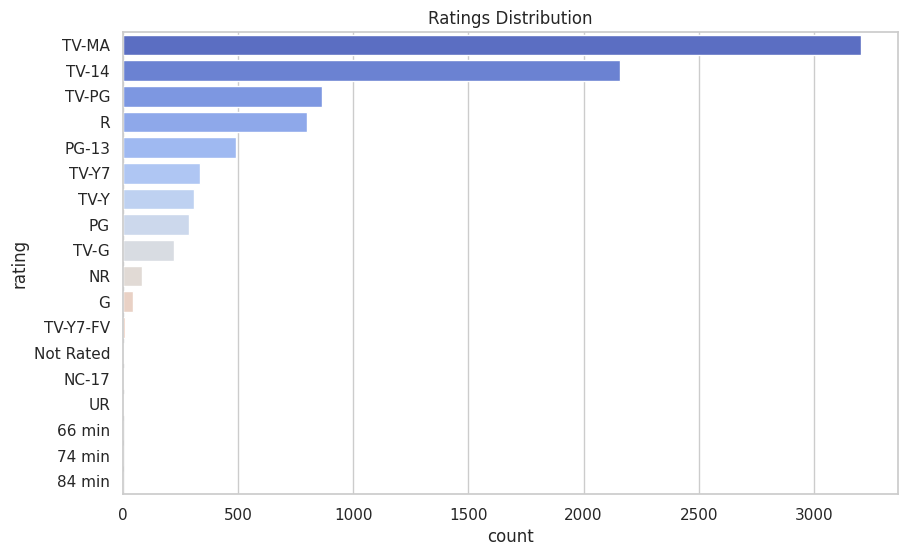

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(y='rating', data=df,
              order=df['rating'].value_counts().index,
              palette='coolwarm')
plt.title('Ratings Distribution')
plt.show()

/tmp/ipykernel_1239/1283954151.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Genre', data=top_genres, palette='viridis')


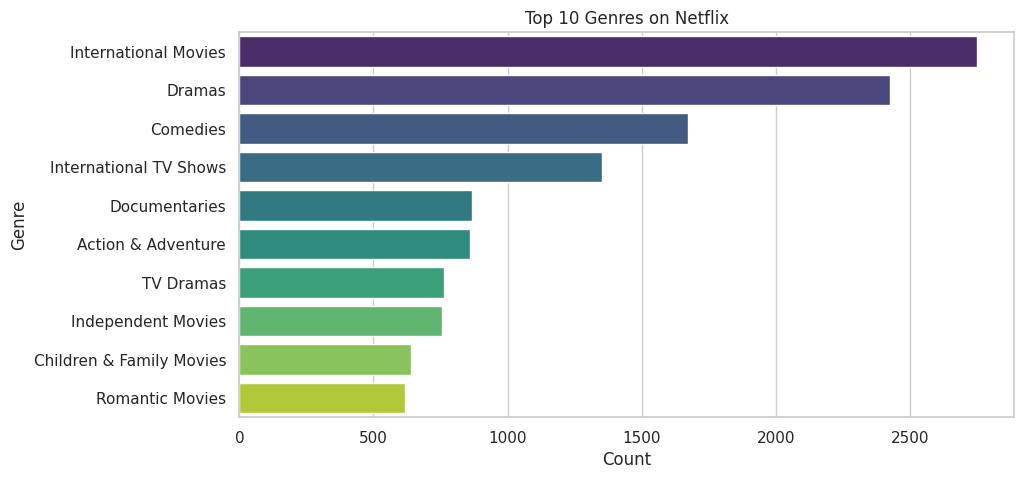

In [ ]:
from collections import Counter

genres = df['listed_in'].str.split(', ')
all_genres = sum(genres, [])

genre_counts = Counter(all_genres)

top_genres = pd.DataFrame(genre_counts.items(), columns=['Genre', 'Count'])
top_genres = top_genres.sort_values(by='Count', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x='Count', y='Genre', data=top_genres, palette='viridis')
plt.title('Top 10 Genres on Netflix')
plt.show()

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1239/3629453658.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)


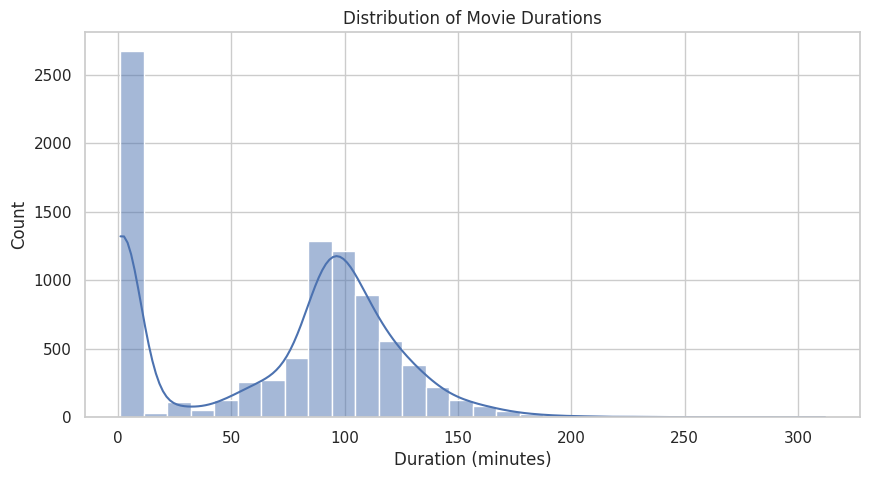

In [ ]:
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)

plt.figure(figsize=(10,5))
sns.histplot(df['duration_num'], bins=30, kde=True)
plt.title('Distribution of Movie Durations')
plt.xlabel('Duration (minutes)')
plt.show()

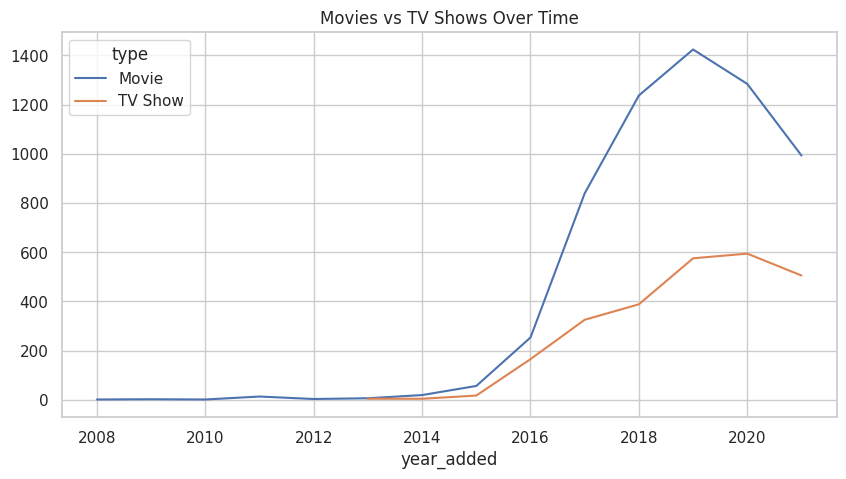

In [ ]:
type_year = df.groupby(['year_added', 'type']).size().unstack()

type_year.plot(figsize=(10,5))
plt.title('Movies vs TV Shows Over Time')
plt.show()

In [ ]:
df['duration_num'] = df['duration'].str.extract('(\d+)')
df['duration_num'] = df['duration_num'].astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1239/1873932214.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['duration_num'] = df['duration'].str.extract('(\d+)')


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['type_encoded'] = le.fit_transform(df['type'])

In [ ]:
features = df[['release_year', 'duration_num', 'type_encoded']].dropna()
features.head()

,release_year,duration_num,type_encoded
0,2020,90.0,0
1,2021,2.0,1
2,2021,1.0,1
3,2021,1.0,1
4,2021,2.0,1


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

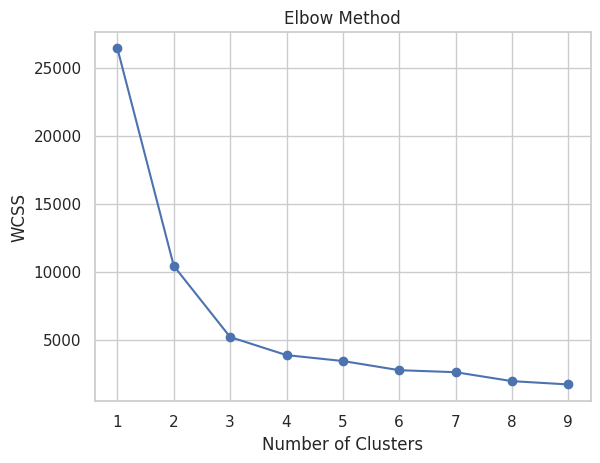

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)

df.loc[features.index, 'cluster'] = kmeans.fit_predict(scaled_features)

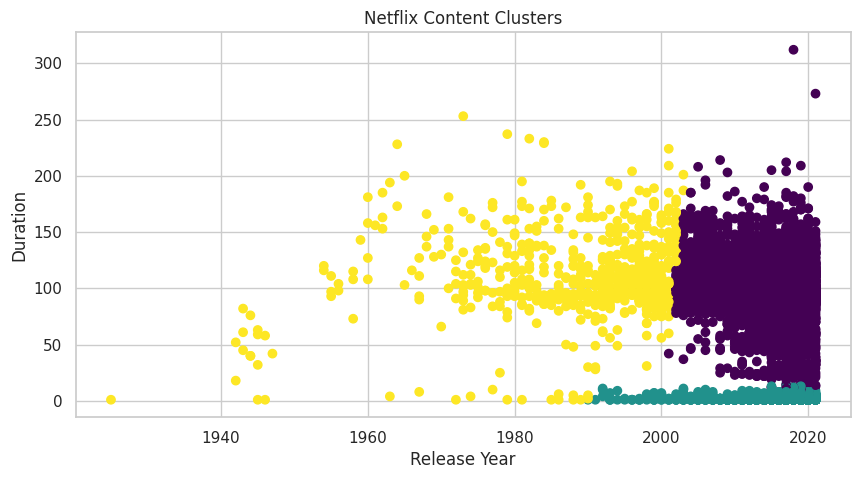

In [ ]:
plt.figure(figsize=(10,5))

plt.scatter(features['release_year'],
            features['duration_num'],
            c=df.loc[features.index, 'cluster'],
            cmap='viridis')

plt.xlabel('Release Year')
plt.ylabel('Duration')
plt.title('Netflix Content Clusters')
plt.show()

In [ ]:
df.groupby('cluster')[['release_year', 'duration_num']].mean()

,release_year,duration_num
cluster,,
0.0,2015.658572,97.868502
1.0,2016.894658,1.756584
2.0,1987.889267,112.797274


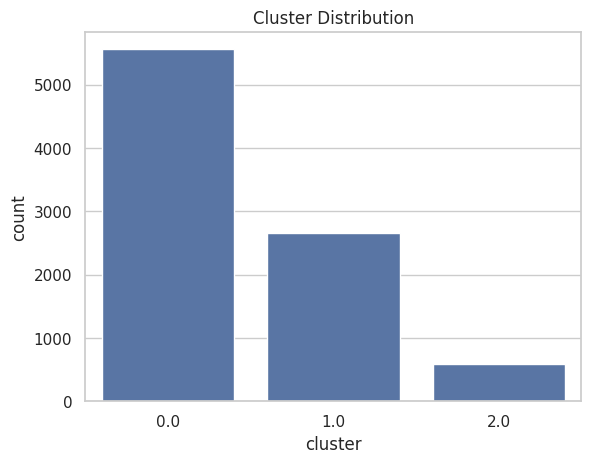

In [ ]:
sns.countplot(x='cluster', data=df)
plt.title('Cluster Distribution')
plt.show()